# Neural Network Function Approximation

This notebook evaluates online Q-learning with a neural-network function approximator on CartPole. Each environment is trained with one agent configuration across 5 random seeds, and the results are summarized with confidence bands.

In [1]:
import sys
from pathlib import Path

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

# Configure path to import agents and shared utils
NOTEBOOK_DIR = Path.cwd()
FUNCTION_APPROX_DIR = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR / "function-approximation"
AGENT_DIR = FUNCTION_APPROX_DIR / "algorithms" / "non-linear-function-approximation"

for path in [str(FUNCTION_APPROX_DIR), str(AGENT_DIR)]:
    if path not in sys.path:
        sys.path.insert(0, path)

from q_learning_v1 import QLearningAgentv1
from q_learning_v2 import QLearningAgentv2
from q_learning_v3 import QLearningAgentv3
from utils import plot_all_metrics


In [14]:
# Experiment Hyperparameters & Environment Configurations
GLOBAL_SEED = 18092026
np.random.seed(GLOBAL_SEED)
SEEDS = np.random.randint(0, 10000, size=5)

# Hyperparameters configs
HIDDEN_DIM = 64
LR = 0.001
GAMMA = 0.99
EPSILON = 1.0
EPSILON_DECAY = 0.998
BUFFER_SIZE = 5000
BATCH_SIZE = 32
TARGET_UPDATE_FREQ = 500

ENV_CONFIGS = {
    "CartPole-v1": {"max_episodes": 3000},
}

AGENT_CLASSES = [
    "agent-v1",
    "agent-v2 - with replay buffer",
    "agent-v3 - with replay buffer and target network"
]

plt.style.use("seaborn-v0_8-whitegrid")


In [15]:
def build_agent(agent_name, env, seed):
    state_dim = int(np.prod(env.observation_space.shape))
    action_dim = env.action_space.n
    hidden_dim = HIDDEN_DIM

    common_config = {
        "state_dim": state_dim,
        "action_dim": action_dim,
        "hidden_dim": hidden_dim,
        "lr": LR,
        "gamma": GAMMA,
        "epsilon": EPSILON,
        "epsilon_decay": EPSILON_DECAY,
        "seed": seed,
    }

    if agent_name == "agent-v1":
        return QLearningAgentv1(**common_config)
    elif "v2" in agent_name:
        return QLearningAgentv2(
            **common_config,
            batch_size=BATCH_SIZE,
            buffer_size=BUFFER_SIZE,
        )
    elif "v3" in agent_name:
        return QLearningAgentv3(
            **common_config,
            target_update_freq=TARGET_UPDATE_FREQ,
            batch_size=BATCH_SIZE,
            buffer_size=BUFFER_SIZE,
        )
    else:
        raise ValueError(f"Unknown agent name: {agent_name}")


def run_experiment(env_id, agent_name, seed, max_episodes):
    env = gym.make(env_id)
    agent = build_agent(agent_name, env, seed)
    history = agent.learn(env, max_episodes=max_episodes)
    env.close()
    return history


def run_all_experiments(env_configs=ENV_CONFIGS, seeds=SEEDS):
    results = {}
    for env_id, config in env_configs.items():
        results[env_id] = {}
        for agent_name in AGENT_CLASSES:
            results[env_id][agent_name] = []
            for seed in seeds:
                print(f"Running {agent_name} on {env_id} (seed={seed})...")
                history = run_experiment(
                    env_id=env_id,
                    agent_name=agent_name,
                    seed=int(seed),
                    max_episodes=config["max_episodes"],
                )
                results[env_id][agent_name].append({"seed": seed, "history": history})
    return results


## Run Experiments

The neural-network Q-learning agent is trained independently for 5 seeds on each environment. The environment and action-space random generators use the same seed as the agent so that runs are reproducible. Curves are aggregated across seeds with a 95% confidence band.

In [ ]:
ACTIVE_ENV_CONFIGS = {
    "CartPole-v1": ENV_CONFIGS["CartPole-v1"]
}

results = run_all_experiments(env_configs=ACTIVE_ENV_CONFIGS, seeds=SEEDS)
results.keys()

# Important notes
# If you want to run this experiments and get the results faster, make sure you setup the max step per episode
# by using `TimeLimit` wrapper in the environment configuration. Without it (the number of step in each episode can be up to 500), running three agents on CartPole-v1 with the obove
# configuration will take about 100 minutes to complete.

Running agent-v1 on CartPole-v1 (seed=3517)...
Running agent-v1 on CartPole-v1 (seed=7199)...
Running agent-v1 on CartPole-v1 (seed=3377)...
Running agent-v1 on CartPole-v1 (seed=4887)...
Running agent-v1 on CartPole-v1 (seed=6277)...
Running agent-v2 - with replay buffer on CartPole-v1 (seed=3517)...
Running agent-v2 - with replay buffer on CartPole-v1 (seed=7199)...
Running agent-v2 - with replay buffer on CartPole-v1 (seed=3377)...
Running agent-v2 - with replay buffer on CartPole-v1 (seed=4887)...
Running agent-v2 - with replay buffer on CartPole-v1 (seed=6277)...
Running agent-v3 - with replay buffer and target network on CartPole-v1 (seed=3517)...
Running agent-v3 - with replay buffer and target network on CartPole-v1 (seed=7199)...
Running agent-v3 - with replay buffer and target network on CartPole-v1 (seed=3377)...
Running agent-v3 - with replay buffer and target network on CartPole-v1 (seed=4887)...
Running agent-v3 - with replay buffer and target network on CartPole-v1 (seed

dict_keys(['CartPole-v1'])

## Visualize Results

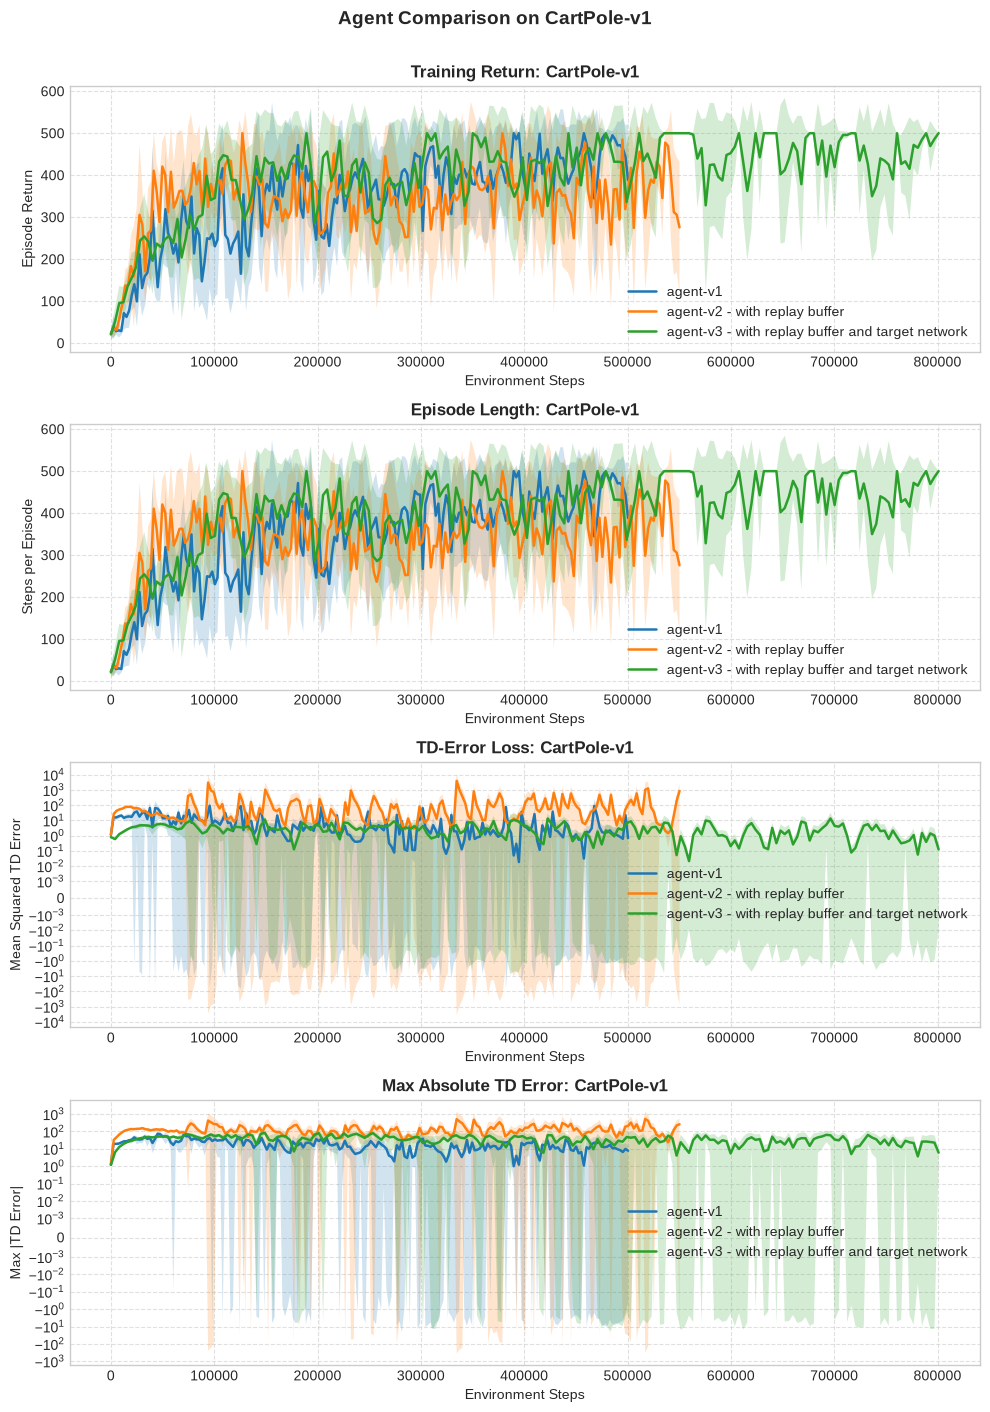

In [17]:
plot_all_metrics(results, env_id="CartPole-v1", x_key="cumulative_steps")
plt.show()


## Interpretation

The main takeaway is that even a small neural network, with just one hidden layer of 64 nodes, can represent nonlinear relationships in the input data. As a result, the plain online-update agent already starts to learn and eventually discovers how to play CartPole, without relying on any additional stabilizing technique. This is a clear contrast with the earlier linear function approximation results: even after adding several techniques, the limited linear representation was not expressive enough to learn effective CartPole behavior.

The three agents also show that replay and target-network techniques aren't independently helpful — it's really about how they interact. The online agent (agent-v1) is noisy but performs reasonably well. Adding a replay buffer alone (agent-v2) doesn't stabilize learning here — its return is generally lower and more unstable than the online agent, and its TD-error loss is the highest and most erratic of the three. That's likely because replay still bootstraps against a constantly shifting network, so sampling more diverse past transitions just adds variance to an already-moving target rather than taming it. The target network is what actually makes the difference: agent-v3, combining replay with a target network, gets stronger, more sustained returns and smoother, gradually decreasing error. So replay and target network seem complementary rather than independently stabilizing — replay only pays off once the bootstrap target is held still; without that, it can amplify instability instead of fixing it.